In [14]:
# ===== CELL 1: Project Information =====

"""
🎓 Graduation Project: Indoor Air Quality Prediction
📊 Model: Logistic Regression
👤 Team Member: FADIA

"""

print("=" * 60)
print("🎯 LOGISTIC REGRESSION MODEL")
print("=" * 60)

🎯 LOGISTIC REGRESSION MODEL


In [35]:
# ===== CELL 2: Import Libraries =====

# Data handling
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import pickle
import time
import joblib
import os

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [16]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# ⚠️ UPDATE THESE LINKS - حطي روابط GitHub تبعكم
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"✅ Data loaded successfully!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")


LOADING DATA
✅ Data loaded successfully!
   X_train: (115200, 10)
   X_test: (28800, 10)
   y_train: (115200,)
   y_test: (28800,)


In [17]:
# ===== CELL 5: Model Configuration =====
# 👤 PERSON 1: Logistic Regression

model = LogisticRegression(
    max_iter=1000,        # Maximum iterations
    random_state=42,       # For reproducibility
    C=1.0,                # Regularization strength
    penalty='l2',         # L2 regularization
    solver='lbfgs',       # Solver algorithm
    multi_class='multinomial',  # For 3 classes
    verbose=1             # Show training progress
)

print("✅ Logistic Regression model configured!")
print(f"\n📋 Model parameters:")
print(f"   - max_iter: {model.max_iter}")
print(f"   - C (regularization): {model.C}")
print(f"   - penalty: {model.penalty}")
print(f"   - solver: {model.solver}")
print(f"   - multi_class: {model.multi_class}")

✅ Logistic Regression model configured!

📋 Model parameters:
   - max_iter: 1000
   - C (regularization): 1.0
   - penalty: l2
   - solver: lbfgs
   - multi_class: multinomial


In [18]:
# ===== CELL 6: Train Model =====

print("🚀 Starting training...")
start_time = time.time()

# Train model
model.fit(X_train, y_train)

# Calculate training time
training_time = time.time() - start_time

print("✅ Training completed!")
print(f"⏱️ Training time: {training_time:.2f} seconds")

🚀 Starting training...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Training completed!
⏱️ Training time: 47.50 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   47.5s finished


In [23]:
print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"✅ Predictions completed!")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_pred_proba.shape}")

print(f"\n🔍 Sample predictions (first 10):")
print(f"   True:      {y_test[:10].values}")
print(f"   Predicted: {y_pred[:10]}")


MAKING PREDICTIONS
✅ Predictions completed!
   Predictions shape: (28800,)
   Probabilities shape: (28800, 3)

🔍 Sample predictions (first 10):
   True:      [2 2 2 2 1 1 0 2 2 1]
   Predicted: [1 1 1 2 0 2 0 2 0 1]


In [25]:
print("\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)

# Class names
class_names = ['Good', 'Moderate', 'Poor']

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Per-class metrics
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

# Print summary
print(f"\n{'='*80}")
print(f"📊 OVERALL PERFORMANCE - Logistic Regression")
print(f"{'='*80}")
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"⏱️  Training Time: {training_time:.2f} seconds")
print(f"{'='*80}")


EVALUATION METRICS

📊 OVERALL PERFORMANCE - Logistic Regression
🎯 Accuracy: 0.4978 (49.78%)
⏱️  Training Time: 47.50 seconds


In [26]:
print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)

print(f"\n{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"{'-'*50}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


PER-CLASS METRICS

Class        Precision    Recall       F1-Score    
--------------------------------------------------
Good         0.5383       0.4094       0.4651      
Moderate     0.4953       0.7863       0.6078      
Poor         0.4216       0.1098       0.1743      

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.54      0.41      0.47      7064
    Moderate       0.50      0.79      0.61     13388
        Poor       0.42      0.11      0.17      8348

    accuracy                           0.50     28800
   macro avg       0.49      0.44      0.42     28800
weighted avg       0.48      0.50      0.45     28800




CONFUSION MATRIX


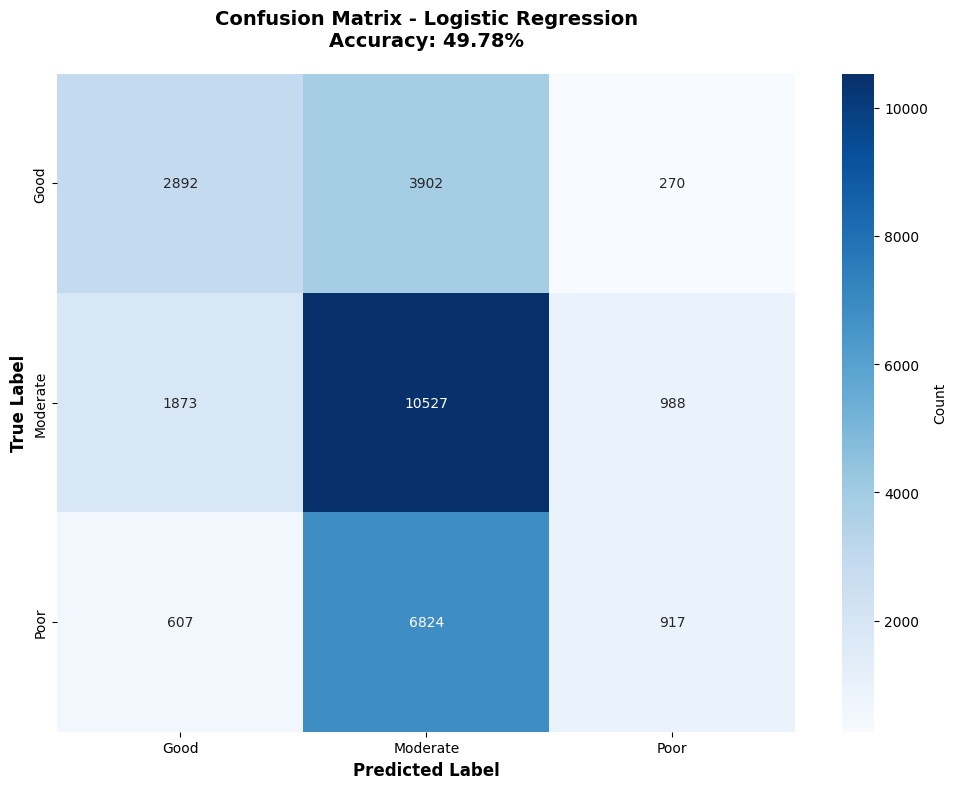


Confusion Matrix Values:
[[ 2892  3902   270]
 [ 1873 10527   988]
 [  607  6824   917]]

✅ Correct predictions: 14336/28800 (49.78%)
❌ Incorrect predictions: 14464/28800 (50.22%)


In [28]:
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Logistic Regression\nAccuracy: {accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print values
print("\nConfusion Matrix Values:")
print(cm)
print(f"\n✅ Correct predictions: {cm.diagonal().sum()}/{cm.sum()} ({cm.diagonal().sum()/cm.sum()*100:.2f}%)")
print(f"❌ Incorrect predictions: {cm.sum() - cm.diagonal().sum()}/{cm.sum()} ({(cm.sum() - cm.diagonal().sum())/cm.sum()*100:.2f}%)")


PERFORMANCE VISUALIZATION


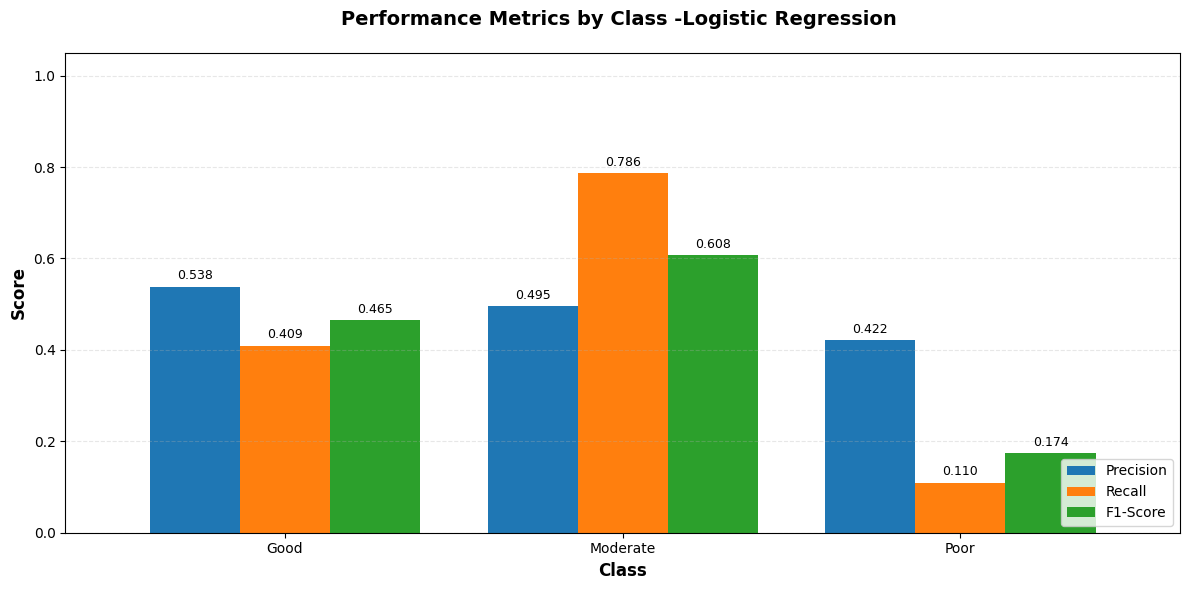

✅ Visualization complete!


In [30]:
print("\n" + "="*80)
print("PERFORMANCE VISUALIZATION")
print("="*80)

# Create dataframe
metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)
plt.title(f'Performance Metrics by Class -Logistic Regression ',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

In [36]:
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

# Save model
model_filename = f'logistic_regression_model.pkl'
joblib.dump(model, model_filename)

# Check file size
file_size_kb = os.path.getsize(model_filename) / 1024

print(f"✅ Model saved successfully!")
print(f"   Filename: {model_filename}")
print(f"   Size: {file_size_kb:.2f} KB")
print(f"\n💡 Download from Files panel (📁 icon on left)")



SAVING MODEL
✅ Model saved successfully!
   Filename: logistic_regression_model.pkl
   Size: 1.47 KB

💡 Download from Files panel (📁 icon on left)
